# Hourly Shift Model Prototype

This notebook starts a clean prototype for household load shifting using only the price forecasts from `XG_Boost_full_Res.py`.

Scope of this prototype:
- use the saved XGBoost `120` hour point forecasts
- combine them with hourly DK1 consumption context
- define simple household segments
- run one transparent first-pass shifting heuristic
- inspect the resulting cost and load-shift effects step by step


## Prototype Notes

This is intentionally not built on the existing simulation scripts.

It uses:
- `outputs/model/predictions.parquet` from `XG_Boost_full_Res.py`
- `data/consumption_dk1_raw.csv`
The first version uses a simple heuristic decision rule so we can see the mechanics clearly before moving to a full optimization model.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hourly_shift_model_v2 import (
    ANNUAL_HEATMAP_DAILY_ISSUES,
    DECISION_WEIGHTS,
    HOUSEHOLD_SHARE_OF_SYSTEM,
    ROLLING_BACKTEST_MAX_WINDOWS,
    SEGMENT_ASSUMPTIONS,
    SEGMENT_COLORS,
    assemble_window_for_issue_time,
    build_historical_segment_capacity,
    build_issue_catalog,
    build_shift_plan,
    load_predictions,
    load_system_load,
    summarize_issue_time_run,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

sum(v["share_of_household_load"] for v in SEGMENT_ASSUMPTIONS.values())

1.0

In [2]:
preds = load_predictions()
issue_catalog = build_issue_catalog(preds)
selected_issue_time = issue_catalog.iloc[-1]["issue_time"]

forecast_window = (
    preds[preds["issue_time"] == selected_issue_time]
    .sort_values("horizon_h")
    .reset_index(drop=True)
)

print(f"Selected issue time: {selected_issue_time}")
print(f"Forecast window rows: {len(forecast_window)}")
display(forecast_window.head())
display(forecast_window.tail())

Selected issue time: 2025-12-31 12:00:00
Forecast window rows: 120


,issue_time,target_time,horizon_h,DayAheadPriceEUR,pred_q10,predicted,pred_q90,fold,fold_end
0,2025-12-31 12:00:00,2025-12-31 13:00:00,1,85.170000,64.636459,95.083870,105.029785,11,2025-10-01
1,2025-12-31 12:00:00,2025-12-31 14:00:00,2,85.177500,58.377899,94.170052,110.257858,11,2025-10-01
2,2025-12-31 12:00:00,2025-12-31 15:00:00,3,90.832498,62.155796,97.701813,114.716965,11,2025-10-01
3,2025-12-31 12:00:00,2025-12-31 16:00:00,4,100.705002,84.151421,105.796936,139.153839,11,2025-10-01
4,2025-12-31 12:00:00,2025-12-31 17:00:00,5,110.099999,90.717567,125.013893,153.291595,11,2025-10-01


,issue_time,target_time,horizon_h,DayAheadPriceEUR,pred_q10,predicted,pred_q90,fold,fold_end
115,2025-12-31 12:00:00,2026-01-05 08:00:00,116,151.175003,90.690140,104.846382,152.595398,11,2025-10-01
116,2025-12-31 12:00:00,2026-01-05 09:00:00,117,152.150001,77.265007,97.316940,120.869690,11,2025-10-01
117,2025-12-31 12:00:00,2026-01-05 10:00:00,118,145.637505,92.294731,104.519600,141.037216,11,2025-10-01
118,2025-12-31 12:00:00,2026-01-05 11:00:00,119,136.702499,84.881218,98.095558,124.809105,11,2025-10-01
119,2025-12-31 12:00:00,2026-01-05 12:00:00,120,134.432503,79.008835,99.720413,138.363129,11,2025-10-01


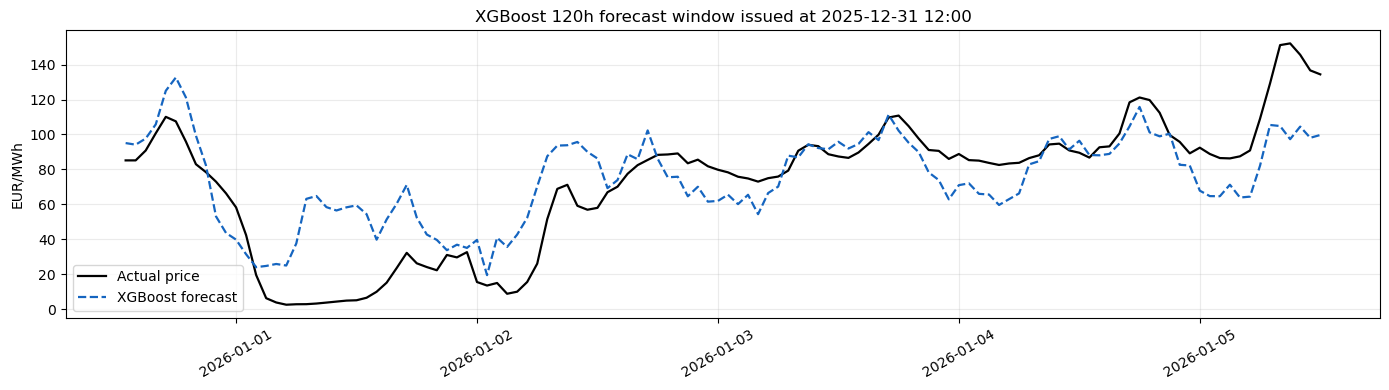

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(forecast_window["target_time"], forecast_window["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.6)
ax.plot(forecast_window["target_time"], forecast_window["predicted"], label="XGBoost forecast", color="#1565C0", linewidth=1.6, linestyle="--")
ax.set_title(f"XGBoost 120h forecast window issued at {selected_issue_time:%Y-%m-%d %H:%M}")
ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()


In [4]:
system_load = load_system_load()
historical_segment_capacity = build_historical_segment_capacity(
    system_load=system_load,
    segment_assumptions=SEGMENT_ASSUMPTIONS,
)
window_df = assemble_window_for_issue_time(
    issue_time=selected_issue_time,
    preds=preds,
    system_load=system_load,
    segment_assumptions=SEGMENT_ASSUMPTIONS,
)

display(
    window_df[
        [
            "target_time",
            "horizon_h",
            "predicted",
            "DayAheadPriceEUR",
            "system_load_mwh",
            "household_load_mwh",
        ]
    ].head()
)

,target_time,horizon_h,predicted,DayAheadPriceEUR,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,1,95.083870,85.170000,2723.044591,898.604715
1,2025-12-31 14:00:00,2,94.170052,85.177500,2614.115651,862.658165
2,2025-12-31 15:00:00,3,97.701813,90.832498,2660.063258,877.820875
3,2025-12-31 16:00:00,4,105.796936,100.705002,2788.393626,920.169897
4,2025-12-31 17:00:00,5,125.013893,110.099999,2872.311541,947.862809


In [5]:
display(window_df[["target_time", "system_load_mwh", "household_load_mwh"]].head())


,target_time,system_load_mwh,household_load_mwh
0,2025-12-31 13:00:00,2723.044591,898.604715
1,2025-12-31 14:00:00,2614.115651,862.658165
2,2025-12-31 15:00:00,2660.063258,877.820875
3,2025-12-31 16:00:00,2788.393626,920.169897
4,2025-12-31 17:00:00,2872.311541,947.862809


In [6]:
segment_table = pd.DataFrame(SEGMENT_ASSUMPTIONS).T
segment_table.index.name = "segment"
display(segment_table)

base_cols = [f"{segment}_baseline_mwh" for segment in SEGMENT_ASSUMPTIONS]
window_df["baseline_household_check_mwh"] = window_df[base_cols].sum(axis=1)
window_df[["target_time", "household_load_mwh", "baseline_household_check_mwh"]].head()

,share_of_household_load,max_shiftable_share,max_wait_h,wait_penalty
segment,,,,
inflexible,0.6,0.00,0.0,0.00
wet_loads,0.1,0.35,48.0,0.90
thermal,0.2,0.15,24.0,1.20
ev,0.1,0.65,120.0,0.35


,target_time,household_load_mwh,baseline_household_check_mwh
0,2025-12-31 13:00:00,898.604715,898.604715
1,2025-12-31 14:00:00,862.658165,862.658165
2,2025-12-31 15:00:00,877.820875,877.820875
3,2025-12-31 16:00:00,920.169897,920.169897
4,2025-12-31 17:00:00,947.862809,947.862809


In [7]:
# Shared shift-planning helpers are imported from hourly_shift_model_v2.py.

In [8]:
prototype_df, shifts_df = build_shift_plan(
    window_df,
    SEGMENT_ASSUMPTIONS,
    DECISION_WEIGHTS,
    historical_segment_capacity,
)

selected_shifted_energy_mwh = float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0
selected_total_system_consumption_mwh = float(prototype_df["system_load_mwh"].sum())
selected_total_household_consumption_mwh = float(prototype_df["household_load_mwh"].sum())

summary = pd.Series(
    {
        "selected_issue_time": selected_issue_time,
        "horizon_hours": len(prototype_df),
        "n_shift_events": int(len(shifts_df)),
        "shifted_energy_mwh": selected_shifted_energy_mwh,
        "modeled_total_system_consumption_mwh": selected_total_system_consumption_mwh,
        "modeled_total_household_consumption_mwh": selected_total_household_consumption_mwh,
        "shifted_share_of_system_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_system_consumption_mwh,
        "shifted_share_of_household_consumption_pct": 100.0 * selected_shifted_energy_mwh / selected_total_household_consumption_mwh,
        "realized_household_savings_eur": float(prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()),
        "predicted_household_savings_eur": float(prototype_df["baseline_predicted_cost_eur"].sum() - prototype_df["shifted_predicted_cost_eur"].sum()),
    }
)


display(summary.to_frame("value"))
display(shifts_df.sort_values("shift_mwh", ascending=False).head(20))
display(historical_segment_capacity)


,value
selected_issue_time,2025-12-31 12:00:00
horizon_hours,120
n_shift_events,212
shifted_energy_mwh,1810.486593
modeled_total_system_consumption_mwh,370418.631059
modeled_total_household_consumption_mwh,122238.148249
shifted_share_of_system_consumption_pct,0.488768
shifted_share_of_household_consumption_pct,1.481114
realized_household_savings_eur,10822.232143
predicted_household_savings_eur,43876.002098


,segment,origin_index,target_index,origin_time,target_time,wait_h,shift_mwh,origin_predicted_price,target_predicted_price,score_gain,chosen_rank,target_segment_capacity_mwh,available_room_before_allocation_mwh,projected_target_segment_load_mwh,remaining_origin_movable_mwh
106,thermal,52,67,2026-01-02 17:00:00,2026-01-03 08:00:00,15,29.576805,102.327499,86.902977,0.066606,14,221.626417,29.576805,221.626417,3.665754
130,thermal,76,96,2026-01-03 17:00:00,2026-01-04 13:00:00,20,28.977334,111.348473,88.254646,0.157396,15,228.356140,28.977334,228.356140,1.737719
100,thermal,45,64,2026-01-02 10:00:00,2026-01-03 05:00:00,19,28.881902,95.720116,66.468636,0.298062,11,195.990830,28.881902,195.990830,1.714253
122,thermal,71,72,2026-01-03 12:00:00,2026-01-03 13:00:00,1,28.464562,95.824959,91.970726,0.049647,11,228.356140,28.464562,228.356140,1.599490
84,thermal,5,7,2025-12-31 18:00:00,2025-12-31 20:00:00,2,28.314795,132.634674,99.371826,0.225077,22,201.866320,29.652905,200.528210,0.000000
103,thermal,46,65,2026-01-02 11:00:00,2026-01-03 06:00:00,19,27.519008,90.065239,70.161240,0.142099,14,201.383890,27.519008,201.383890,3.942911
82,thermal,4,8,2025-12-31 17:00:00,2025-12-31 21:00:00,4,27.469470,125.013893,82.344780,0.274381,19,199.378370,27.469470,199.378370,0.966415
132,thermal,77,97,2026-01-03 18:00:00,2026-01-04 14:00:00,20,26.236654,102.181473,88.084099,0.000939,16,223.909268,26.236654,223.909268,5.597982
78,thermal,2,9,2025-12-31 15:00:00,2025-12-31 22:00:00,7,26.124650,97.701813,53.126102,0.258429,9,194.196548,37.888705,182.432493,0.000000
76,thermal,1,10,2025-12-31 14:00:00,2025-12-31 23:00:00,9,25.879745,94.170052,43.624702,0.282413,7,191.118063,26.089721,190.908086,0.000000


,hour_of_day,inflexible_historical_cap_mwh,wet_loads_historical_cap_mwh,thermal_historical_cap_mwh,ev_historical_cap_mwh
0,0,595.221167,99.203528,198.407056,99.203528
1,1,597.712792,99.618799,199.237597,99.618799
2,2,601.029110,100.171518,200.343037,100.171518
3,3,600.386670,100.064445,200.128890,100.064445
4,4,590.214002,98.369000,196.738001,98.369000
5,5,587.972491,97.995415,195.990830,97.995415
6,6,604.151669,100.691945,201.383890,100.691945
7,7,644.096095,107.349349,214.698698,107.349349
8,8,664.879252,110.813209,221.626417,110.813209
9,9,667.104013,111.184002,222.368004,111.184002


## Rolling Backtest Setup

The single-window prototype is useful for inspection, but the next step is to test the heuristic over many historical XGBoost forecast issue times.

Two views are useful:
- a `daily` rolling backtest at `12:00` issue times to see stability over time
- a `non-overlapping` subset sampled every `5` days so total shifted MWh can be compared cleanly with total modeled consumption without double-counting overlapping horizons


In [9]:
# Shared rolling-window helpers are imported from hourly_shift_model_v2.py.

In [10]:
daily_issue_times = issue_catalog.loc[issue_catalog["issue_time"].dt.hour == 12, "issue_time"].reset_index(drop=True)
backtest_issue_times = daily_issue_times.tail(ROLLING_BACKTEST_MAX_WINDOWS).reset_index(drop=True)
non_overlapping_issue_times = backtest_issue_times.iloc[::5].reset_index(drop=True)

display(
    pd.Series(
        {
            "available_full_120h_issue_times": int(len(issue_catalog)),
            "available_daily_12h_issue_times": int(len(daily_issue_times)),
            "rolling_backtest_daily_windows": int(len(backtest_issue_times)),
            "non_overlapping_5day_windows": int(len(non_overlapping_issue_times)),
        }
    ).to_frame("value")
)

,value
available_full_120h_issue_times,2162
available_daily_12h_issue_times,1081
rolling_backtest_daily_windows,120
non_overlapping_5day_windows,24


In [11]:
rolling_backtest_df = pd.DataFrame(
    [
        summarize_issue_time_run(
            issue_time=issue_time,
            preds=preds,
            system_load=system_load,
            household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
            segment_assumptions=SEGMENT_ASSUMPTIONS,
            decision_weights=DECISION_WEIGHTS,
            historical_segment_capacity=historical_segment_capacity,
        )
        for issue_time in backtest_issue_times
    ]
)

non_overlapping_backtest_df = rolling_backtest_df[
    rolling_backtest_df["issue_time"].isin(non_overlapping_issue_times)
].copy()

display(rolling_backtest_df.head())


,issue_time,horizon_hours,n_shift_events,shifted_energy_mwh,modeled_total_system_consumption_mwh,modeled_total_household_consumption_mwh,shifted_share_of_system_consumption_pct,shifted_share_of_household_consumption_pct,realized_household_savings_eur,predicted_household_savings_eur
0,2025-09-03 12:00:00,120,327,5252.059119,286822.151449,94651.309978,1.831120,5.548850,242177.808281,184248.873672
1,2025-09-04 12:00:00,120,334,5338.324085,281072.875098,92754.048782,1.899267,5.755354,281485.863125,210480.447360
2,2025-09-05 12:00:00,120,336,5126.253935,281616.542155,92933.458911,1.820296,5.516048,312595.462185,205737.532736
3,2025-09-06 12:00:00,120,333,4915.656119,290700.285185,95931.094111,1.690971,5.124153,284841.118814,169743.496895
4,2025-09-07 12:00:00,120,311,4574.901821,303970.574901,100310.289717,1.505048,4.560750,299809.596003,167875.012014


## Rolling Backtest Summary

The daily backtest shows how stable the prototype is over time. The non-overlapping summary is the cleanest answer to the question "how much MWh did we shift relative to the total consumption we modeled?" because it avoids counting overlapping 120-hour horizons multiple times.


In [12]:
rolling_summary = pd.Series(
    {
        "daily_windows_evaluated": int(len(rolling_backtest_df)),
        "avg_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].mean()),
        "median_shifted_energy_mwh_per_120h_window": float(rolling_backtest_df["shifted_energy_mwh"].median()),
        "avg_shifted_share_of_system_consumption_pct": float(rolling_backtest_df["shifted_share_of_system_consumption_pct"].mean()),
        "avg_shifted_share_of_household_consumption_pct": float(rolling_backtest_df["shifted_share_of_household_consumption_pct"].mean()),
        "avg_realized_household_savings_eur": float(rolling_backtest_df["realized_household_savings_eur"].mean()),
    }
)

non_overlapping_summary = pd.Series(
    {
        "non_overlapping_120h_windows": int(len(non_overlapping_backtest_df)),
        "total_shifted_energy_mwh": float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()),
        "total_modeled_system_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "total_modeled_household_consumption_mwh": float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_system_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_system_consumption_mwh"].sum()),
        "shifted_share_of_total_modeled_household_consumption_pct": 100.0 * float(non_overlapping_backtest_df["shifted_energy_mwh"].sum()) / float(non_overlapping_backtest_df["modeled_total_household_consumption_mwh"].sum()),
        "total_realized_household_savings_eur": float(non_overlapping_backtest_df["realized_household_savings_eur"].sum()),
    }
)

display(rolling_summary.to_frame("value"))
display(non_overlapping_summary.to_frame("value"))


,value
daily_windows_evaluated,120.000000
avg_shifted_energy_mwh_per_120h_window,3772.550079
median_shifted_energy_mwh_per_120h_window,3868.204913
avg_shifted_share_of_system_consumption_pct,1.165984
avg_shifted_share_of_household_consumption_pct,3.533284
avg_realized_household_savings_eur,115890.825022


,value
non_overlapping_120h_windows,2.400000e+01
total_shifted_energy_mwh,9.171401e+04
total_modeled_system_consumption_mwh,7.944184e+06
total_modeled_household_consumption_mwh,2.621581e+06
shifted_share_of_total_modeled_system_consumption_pct,1.154480e+00
shifted_share_of_total_modeled_household_consumption_pct,3.498424e+00
total_realized_household_savings_eur,2.844688e+06


## Granular Shift Illustration

The next views give a more detailed picture of how the heuristic moves load:
- an hour-by-hour detail view for the selected `120h` window
- a stacked segment view of shifted household energy hour by hour
- an average net-shift heatmap by day of week and hour of day across the rolling backtest


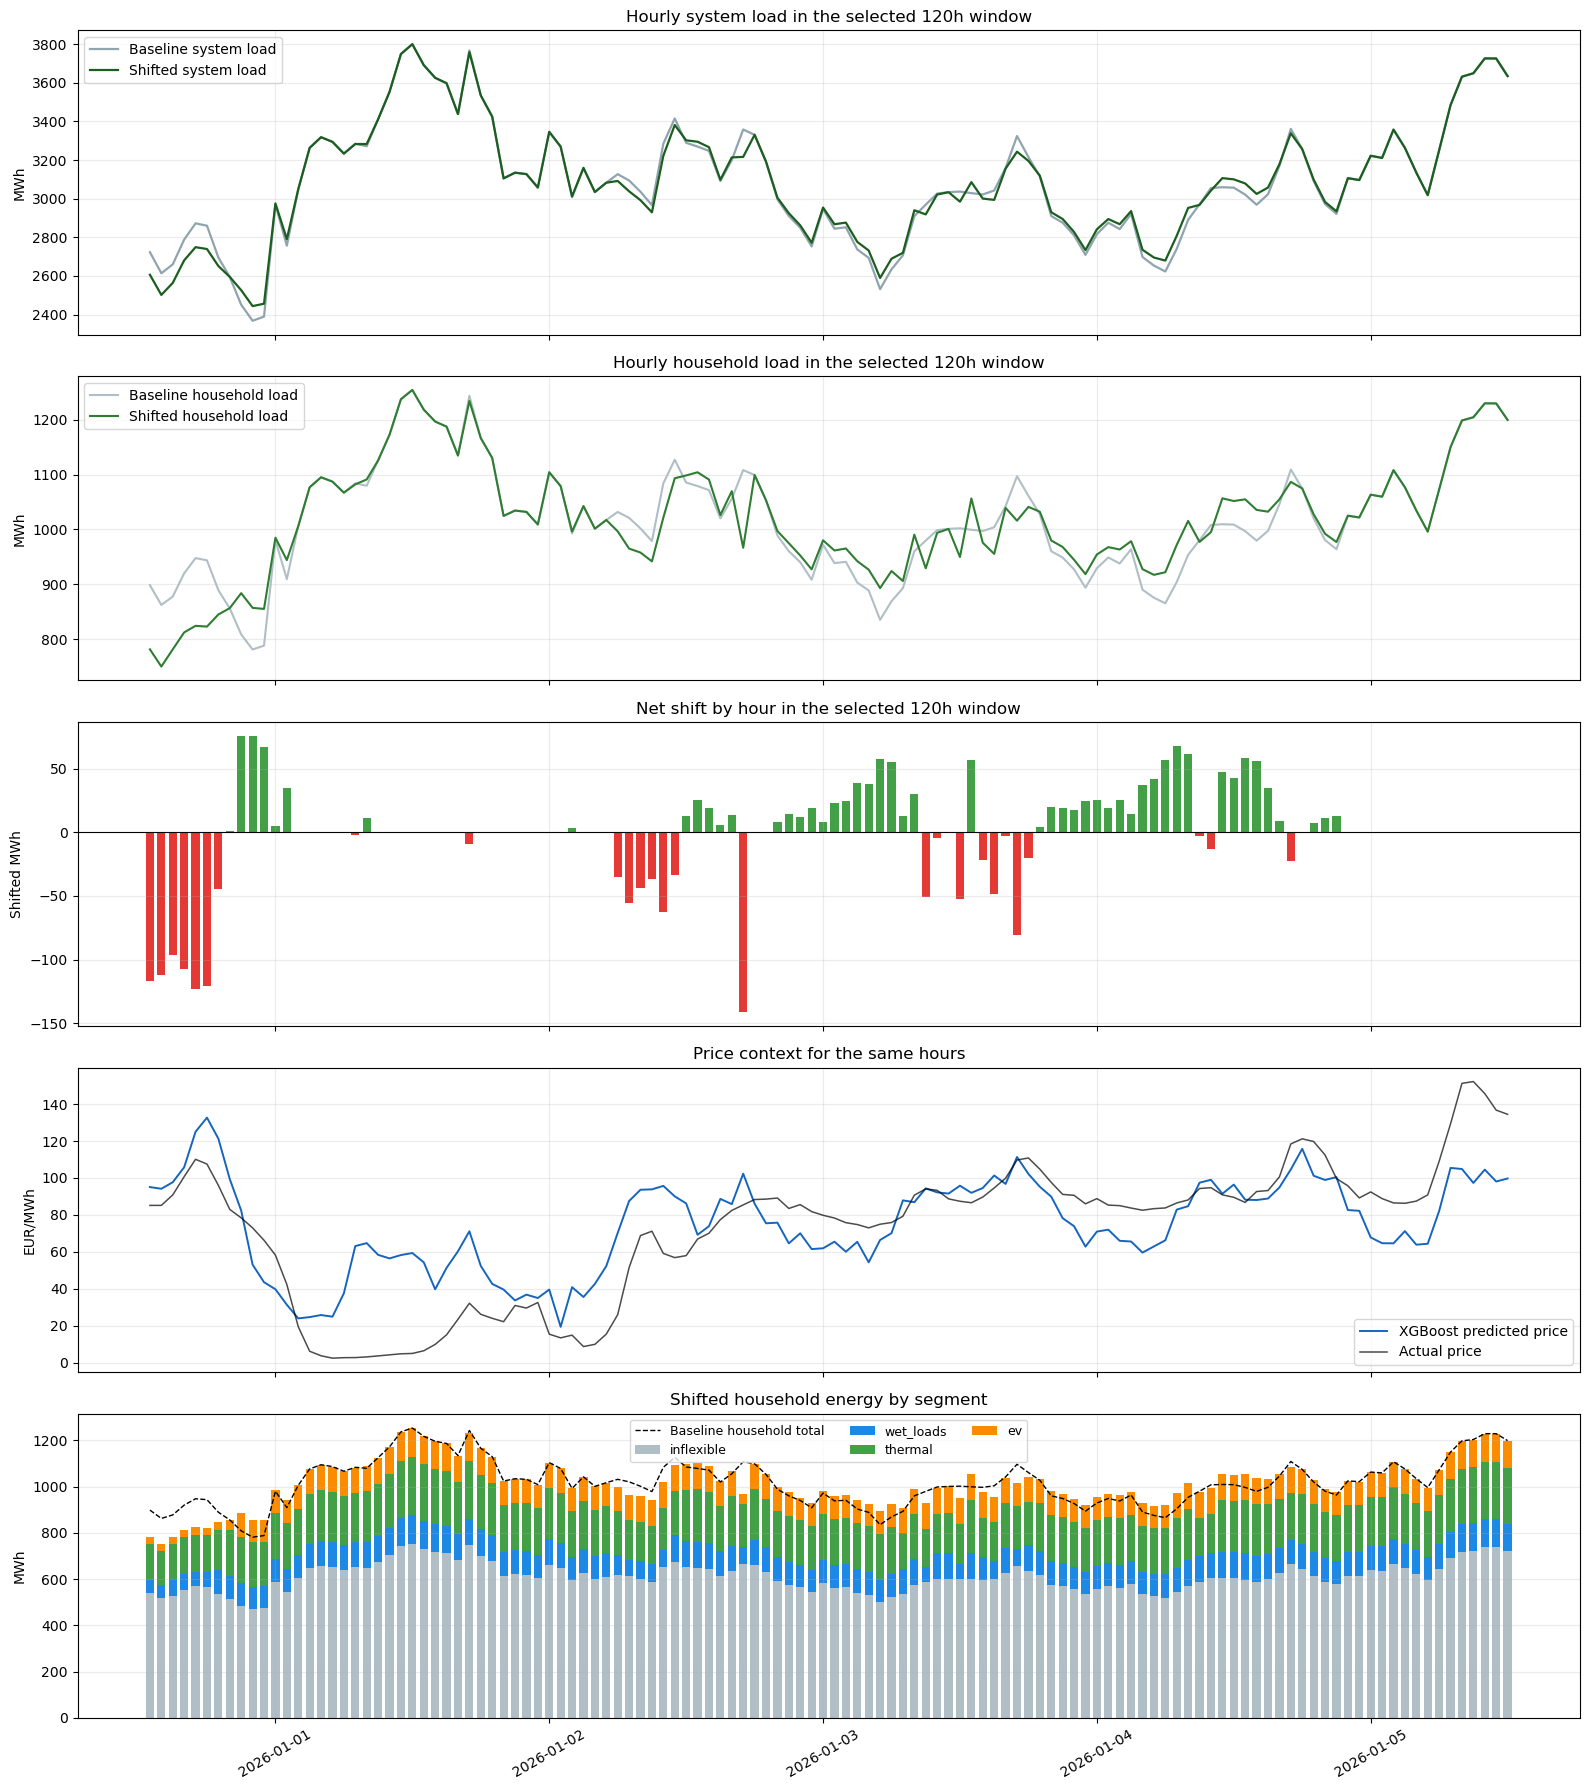

In [13]:
detail_df = prototype_df.copy()
detail_df["net_shift_mwh"] = detail_df["shifted_system_load_mwh"] - detail_df["system_load_mwh"]

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

axes[0].plot(detail_df["target_time"], detail_df["system_load_mwh"], label="Baseline system load", color="#90A4AE", linewidth=1.6)
axes[0].plot(detail_df["target_time"], detail_df["shifted_system_load_mwh"], label="Shifted system load", color="#1B5E20", linewidth=1.6)
axes[0].set_title("Hourly system load in the selected 120h window")
axes[0].set_ylabel("MWh")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(detail_df["target_time"], detail_df["household_load_mwh"], label="Baseline household load", color="#B0BEC5", linewidth=1.5)
axes[1].plot(detail_df["target_time"], detail_df["shifted_household_load_mwh"], label="Shifted household load", color="#2E7D32", linewidth=1.5)
axes[1].set_title("Hourly household load in the selected 120h window")
axes[1].set_ylabel("MWh")
axes[1].grid(alpha=0.25)
axes[1].legend()

bar_colors = np.where(detail_df["net_shift_mwh"] >= 0, "#43A047", "#E53935")
axes[2].bar(detail_df["target_time"], detail_df["net_shift_mwh"], color=bar_colors, width=0.03)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Net shift by hour in the selected 120h window")
axes[2].set_ylabel("Shifted MWh")
axes[2].grid(alpha=0.25)

axes[3].plot(detail_df["target_time"], detail_df["predicted"], label="XGBoost predicted price", color="#1565C0", linewidth=1.4)
axes[3].plot(detail_df["target_time"], detail_df["DayAheadPriceEUR"], label="Actual price", color="black", linewidth=1.1, alpha=0.7)
axes[3].set_title("Price context for the same hours")
axes[3].set_ylabel("EUR/MWh")
axes[3].grid(alpha=0.25)
axes[3].legend()

segment_order = list(SEGMENT_ASSUMPTIONS.keys())
stack_bottom = np.zeros(len(detail_df))
for segment in segment_order:
    shifted_col = f"{segment}_shifted_mwh"
    axes[4].bar(
        detail_df["target_time"],
        detail_df[shifted_col],
        bottom=stack_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
        label=segment,
    )
    stack_bottom = stack_bottom + detail_df[shifted_col].to_numpy()
axes[4].plot(
    detail_df["target_time"],
    detail_df["household_load_mwh"],
    color="black",
    linewidth=1.0,
    linestyle="--",
    label="Baseline household total",
)
axes[4].set_title("Shifted household energy by segment")
axes[4].set_ylabel("MWh")
axes[4].grid(alpha=0.25)
axes[4].legend(ncol=3, fontsize=9)

plt.xticks(rotation=30)
plt.tight_layout()


In [14]:
rolling_hour_pattern = rolling_backtest_df.copy()

annual_issue_times = daily_issue_times.tail(ANNUAL_HEATMAP_DAILY_ISSUES).reset_index(drop=True)
annual_non_overlapping_issue_times = annual_issue_times.iloc[::5].reset_index(drop=True)

annual_profiles = []

for issue_time in annual_non_overlapping_issue_times:
    annual_window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=SEGMENT_ASSUMPTIONS,
    )
    annual_profile_df, _ = build_shift_plan(
        annual_window_df,
        SEGMENT_ASSUMPTIONS,
        DECISION_WEIGHTS,
        historical_segment_capacity,
    )
    annual_profile_df = annual_profile_df.copy()
    annual_profile_df["issue_time"] = pd.Timestamp(issue_time)
    annual_profile_df["date"] = annual_profile_df["target_time"].dt.date
    annual_profile_df["hour"] = annual_profile_df["target_time"].dt.hour
    annual_profile_df["day_of_week"] = annual_profile_df["target_time"].dt.day_name()
    annual_profile_df["net_shift_mwh"] = annual_profile_df["shifted_system_load_mwh"] - annual_profile_df["system_load_mwh"]
    annual_profiles.append(annual_profile_df)

annual_profiles_df = pd.concat(annual_profiles, ignore_index=True)

display(
    pd.Series(
        {
            "annual_daily_issue_times_available": int(len(annual_issue_times)),
            "annual_non_overlapping_120h_windows": int(len(annual_non_overlapping_issue_times)),
            "annual_profile_hours": int(len(annual_profiles_df)),
            "annual_start": str(annual_profiles_df["target_time"].min()),
            "annual_end": str(annual_profiles_df["target_time"].max()),
        }
    ).to_frame("value")
)


,value
annual_daily_issue_times_available,365
annual_non_overlapping_120h_windows,73
annual_profile_hours,8760
annual_start,2024-12-27 13:00:00
annual_end,2026-01-01 12:00:00


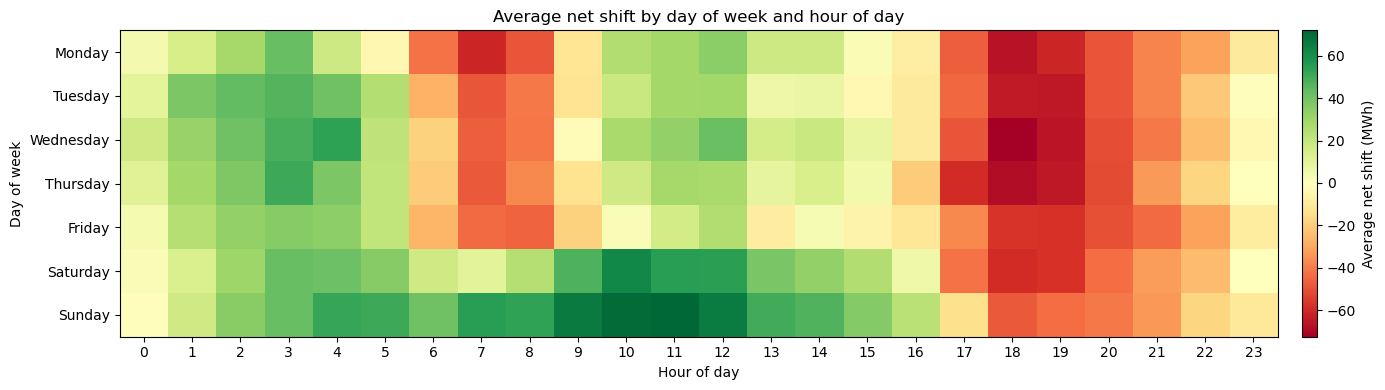

In [15]:
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

net_shift_heatmap = (
    annual_profiles_df.groupby(["day_of_week", "hour"], as_index=False)["net_shift_mwh"]
    .mean()
    .assign(day_of_week=lambda df: pd.Categorical(df["day_of_week"], categories=dow_order, ordered=True))
    .sort_values(["day_of_week", "hour"])
    .pivot(index="day_of_week", columns="hour", values="net_shift_mwh")
)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(net_shift_heatmap.to_numpy(), aspect="auto", cmap="RdYlGn", interpolation="nearest")
ax.set_title("Average net shift by day of week and hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_xticks(np.arange(24))
ax.set_yticks(np.arange(len(net_shift_heatmap.index)))
ax.set_yticklabels(net_shift_heatmap.index.tolist())
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Average net shift (MWh)")
plt.tight_layout()


## 20-Day Segment Net Shift Timeline

This view uses `4` non-overlapping `120h` windows to create a continuous `20` day sample. Bars below zero show energy moved away from an hour, while bars above zero show energy added to that hour.


,value
plot_days,20
plot_hours,480
plot_start,2025-12-12 13:00:00
plot_end,2026-01-01 12:00:00


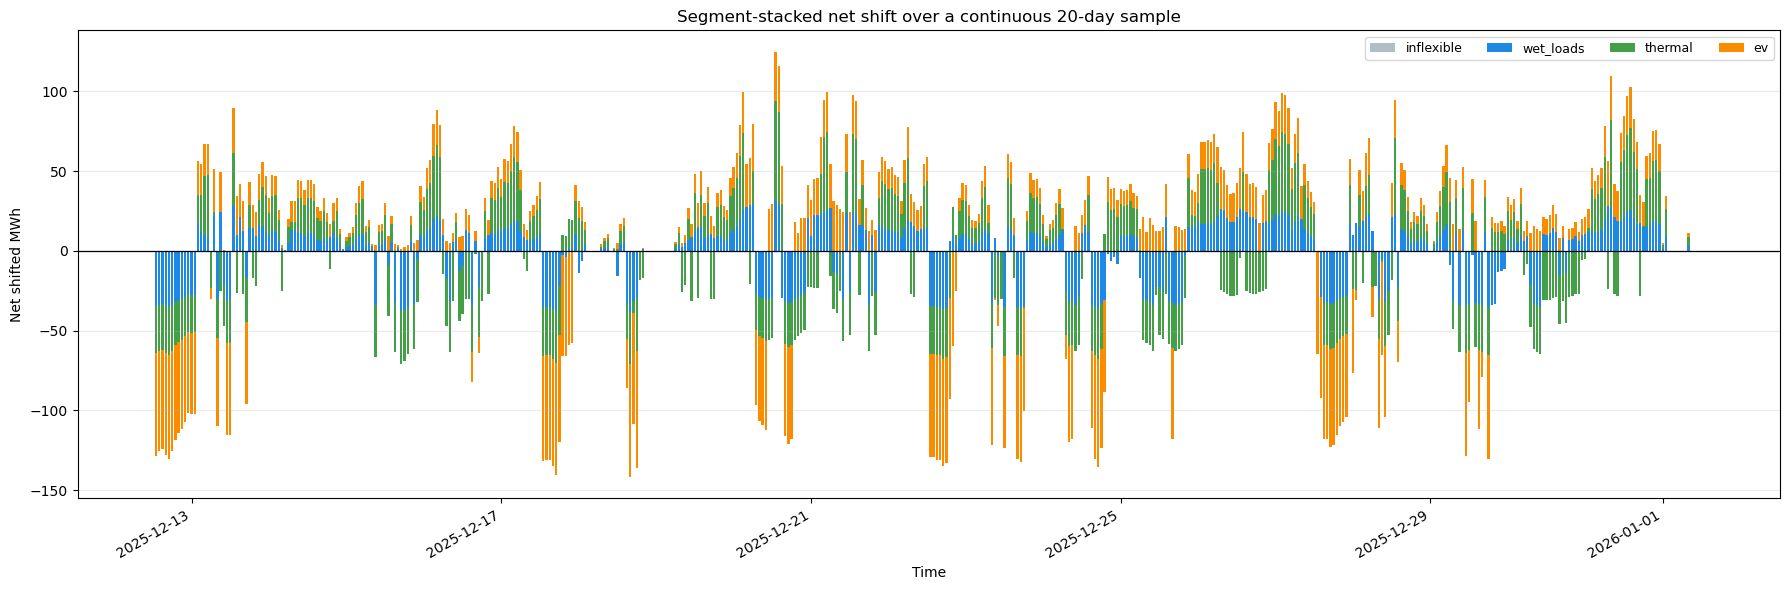

In [16]:
plot_20d_issue_times = annual_non_overlapping_issue_times.tail(4).reset_index(drop=True)

segment_net_shift_profiles = []

for issue_time in plot_20d_issue_times:
    plot_window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=SEGMENT_ASSUMPTIONS,
    )
    plot_profile_df, _ = build_shift_plan(
        plot_window_df,
        SEGMENT_ASSUMPTIONS,
        DECISION_WEIGHTS,
        historical_segment_capacity,
    )
    plot_profile_df = plot_profile_df.copy()
    plot_profile_df["issue_time"] = pd.Timestamp(issue_time)
    segment_net_shift_profiles.append(plot_profile_df)

net_shift_20d_df = (
    pd.concat(segment_net_shift_profiles, ignore_index=True)
    .sort_values("target_time")
    .drop_duplicates(subset=["target_time"], keep="first")
    .reset_index(drop=True)
)

segment_order = list(SEGMENT_ASSUMPTIONS.keys())
for segment in segment_order:
    baseline_col = f"{segment}_baseline_mwh"
    shifted_col = f"{segment}_shifted_mwh"
    net_col = f"{segment}_net_shift_mwh"
    net_shift_20d_df[net_col] = net_shift_20d_df[shifted_col] - net_shift_20d_df[baseline_col]

display(
    pd.Series(
        {
            "plot_days": int(len(net_shift_20d_df) / 24),
            "plot_hours": int(len(net_shift_20d_df)),
            "plot_start": str(net_shift_20d_df["target_time"].min()),
            "plot_end": str(net_shift_20d_df["target_time"].max()),
        }
    ).to_frame("value")
)

fig, ax = plt.subplots(figsize=(18, 6))

positive_bottom = np.zeros(len(net_shift_20d_df))
negative_bottom = np.zeros(len(net_shift_20d_df))

for segment in segment_order:
    net_col = f"{segment}_net_shift_mwh"
    values = net_shift_20d_df[net_col].to_numpy(dtype=float)
    positive_values = np.clip(values, 0, None)
    negative_values = np.clip(values, None, 0)

    ax.bar(
        net_shift_20d_df["target_time"],
        positive_values,
        bottom=positive_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
        label=segment,
    )
    ax.bar(
        net_shift_20d_df["target_time"],
        negative_values,
        bottom=negative_bottom,
        width=0.03,
        color=SEGMENT_COLORS.get(segment, None),
    )

    positive_bottom = positive_bottom + positive_values
    negative_bottom = negative_bottom + negative_values

ax.axhline(0, color="black", linewidth=0.9)
ax.set_title("Segment-stacked net shift over a continuous 20-day sample")
ax.set_xlabel("Time")
ax.set_ylabel("Net shifted MWh")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=4, fontsize=9)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
